# Gaussian Beam Characterization Using Numerical Curve Fitting

## Objective

To simulate a Gaussian beam intensity profile, introduce experimental noise, and recover beam parameters using nonlinear curve fitting. The project also evaluates the quality of fit using residual analysis and parameter sensitivity.

## Theory

A Gaussian beam intensity distribution is given by:

I(x) = I₀ exp(-2x² / w²)

where:
- I₀: peak intensity
- w: beam waist (radius at 1/e² intensity)
- x: transverse position

In experimental optics, measured intensity data often contains noise due to detector limitations, background fluctuations, and system imperfections.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

In [7]:
x = np.linspace(-5, 5, 100)

I0_true = 100
w_true = 2

true_signal = I0_true * np.exp(-2 * x**2 / w_true**2)

noise = np.random.normal(0, 5, len(x))
measured = true_signal + noise

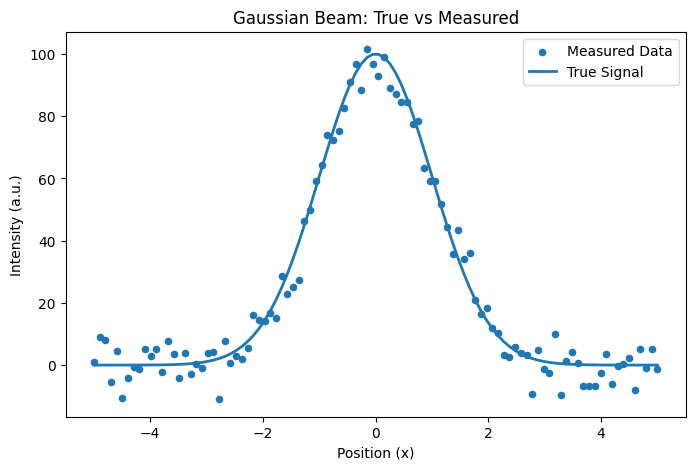

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(x, measured, label="Measured Data", s=20)
plt.plot(x, true_signal, label="True Signal", linewidth=2)

plt.xlabel("Position (x)")
plt.ylabel("Intensity (a.u.)")
plt.title("Gaussian Beam: True vs Measured")
plt.legend()
plt.show()

In [9]:
def gaussian(x, I0, w):
    return I0 * np.exp(-2 * x**2 / w**2)

In [10]:
params, covariance = curve_fit(gaussian, x, measured, p0=[90, 1.5])

I0_fit, w_fit = params

print("Fitted I0:", I0_fit)
print("Fitted w:", w_fit)

Fitted I0: 96.95185017274034
Fitted w: 2.0194659038219362


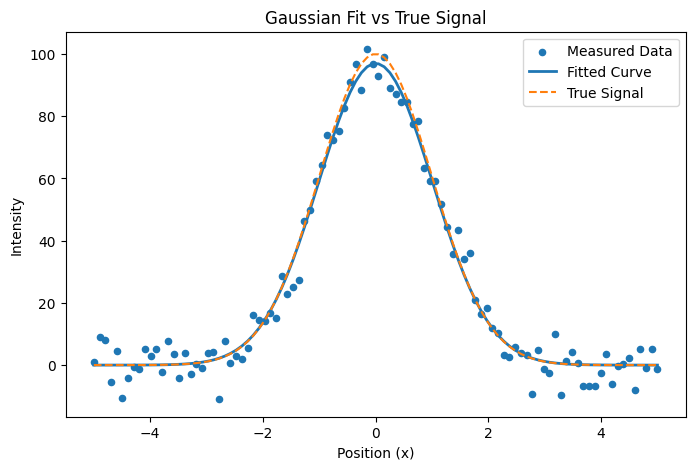

In [11]:
fit_curve = gaussian(x, I0_fit, w_fit)

plt.figure(figsize=(8,5))

plt.scatter(x, measured, label="Measured Data", s=20)
plt.plot(x, fit_curve, label="Fitted Curve", linewidth=2)
plt.plot(x, true_signal, linestyle="dashed", label="True Signal")

plt.xlabel("Position (x)")
plt.ylabel("Intensity")
plt.title("Gaussian Fit vs True Signal")
plt.legend()
plt.show()

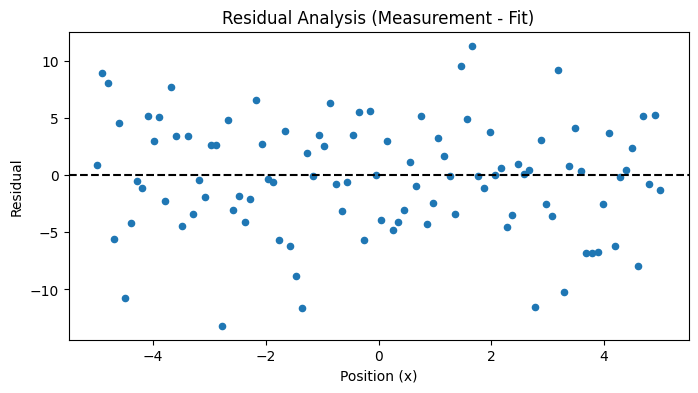

In [12]:
residuals = measured - fit_curve

plt.figure(figsize=(8,4))
plt.scatter(x, residuals, s=20)
plt.axhline(0, color='black', linestyle='--')

plt.title("Residual Analysis (Measurement - Fit)")
plt.xlabel("Position (x)")
plt.ylabel("Residual")
plt.show()

In [13]:
errors = np.sqrt(np.diag(covariance))

print("I0 uncertainty:", errors[0])
print("w uncertainty:", errors[1])

I0 uncertainty: 1.447423396115701
w uncertainty: 0.034813276656829886


## Results and Scientific Interpretation

The Gaussian model successfully captures the transverse intensity distribution of the simulated beam, even in the presence of additive experimental noise.

### Physical Interpretation

- The fitted beam waist (w) represents the effective spatial confinement of the optical field.
- Small deviations in the fit arise from stochastic noise, analogous to detector fluctuations in real optical experiments.
- The residual distribution remains centered around zero, indicating that no systematic model bias is observed.

### Measurement Quality Assessment

Residual analysis shows that deviations are randomly distributed rather than structured, suggesting that:
- The Gaussian model is physically appropriate for this system
- Experimental noise dominates over model mismatch

### Parameter Reliability

The covariance-based uncertainty estimate provides a quantitative measure of confidence in extracted beam parameters, which is essential in experimental photonics and optical metrology.

### Limitations

This model assumes:
- ideal Gaussian beam propagation
- independent additive noise
- no optical aberrations or mode distortions

In real experimental systems, deviations from ideal Gaussian behavior may arise due to:
- optical misalignment
- multimode beam profiles
- detector nonlinearities